In [1]:
import signac
import os
import sys
import pandas as pd
import shutil
import nglview as nv
import MDAnalysis as mda
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.cm as cm
import itertools

In [2]:
path_git='/home/lucia/cc/cascade_computing' #todo - path to git
sys.path.append(path_git)
print(os.path.exists(os.path.join(path_git, 'src')))

True


In [3]:
from src.compute.signac import sgnc
print(f"Location of sgnc: {sgnc.__file__}")

/home/lucia/.local/share/virtualenvs/cascade_computing-KZoXfmvW/lib/python3.10/site-packages/mdtraj/geometry/order.py:25: UserWarning: pkg_resources is deprecated as an API. See https://setuptools.pypa.io/en/latest/pkg_resources.html. The pkg_resources package is slated for removal as early as 2025-11-30. Refrain from using this package or pin to Setuptools<81.
  from pkg_resources import parse_version


Location of sgnc: /home/lucia/cc/cascade_computing/src/compute/signac/sgnc.py


In [4]:
from src.compute.signac import sgnc as sgnc
from src.compute.utils import toolbox_plots as ptools
from src.compute.utils import toolbox_normalization as ntools

In [5]:
p_name='MUT16_FFR_atm_analysis' 
path=path_git+'/examples' 
project_path= path +'/' + p_name

In [6]:
#path to downloaded data
path_data='./data_MUT16_FRR' #todo -put path to your data

In [7]:
project= sgnc.MyProject.get_project(project_path)
project

,sp.mols,sp.n_mols,sp.geo_mols,sp.replica_index,sp.structure_index,doc.domains,doc.output_path,doc.top,doc.top_mix,doc.top_org,...,doc.res_org_prob,doc.res_org_freq,doc.res_org_perc,doc.data_path,doc.struc_id_prob,doc.struc_id_freq,doc.struc_id_perc,doc.res_dom_prob,doc.res_dom_freq,doc.res_dom_perc
0d63eebfbb407ae4862219064b7113ae,"[[MUT16], []]","[65, 0]",[/lustre/miifs01/project/m2_trr146/lubaltz/gmx...,1,0,[],/home/lucia/cc/data_examples/data_MUT16_FRR0d6...,/lustre/miifs01/project/m2_trr146/kugaurav/MUT...,/lustre/miifs01/project/m2_trr146/kugaurav/MUT...,/lustre/miifs01/project/m2_trr146/kugaurav/MUT...,...,./data_MUT16_FRR/0d63eebfbb407ae4862219064b711...,./data_MUT16_FRR/0d63eebfbb407ae4862219064b711...,./data_MUT16_FRR/0d63eebfbb407ae4862219064b711...,./data_MUT16_FRR/0d63eebfbb407ae4862219064b711...,./data_MUT16_FRR/0d63eebfbb407ae4862219064b711...,./data_MUT16_FRR/0d63eebfbb407ae4862219064b711...,./data_MUT16_FRR/0d63eebfbb407ae4862219064b711...,./data_MUT16_FRR/0d63eebfbb407ae4862219064b711...,./data_MUT16_FRR/0d63eebfbb407ae4862219064b711...,./data_MUT16_FRR/0d63eebfbb407ae4862219064b711...
46af39bf2445d01c22c25aadf9d305c4,"[[MUT16], []]","[65, 0]",[/lustre/miifs01/project/m2_trr146/lubaltz/gmx...,6,0,[],/home/lucia/cc/data_examples/data_MUT16_FRR46a...,/lustre/miifs01/project/m2_trr146/kugaurav/MUT...,/lustre/miifs01/project/m2_trr146/kugaurav/MUT...,/lustre/miifs01/project/m2_trr146/kugaurav/MUT...,...,./data_MUT16_FRR/46af39bf2445d01c22c25aadf9d30...,./data_MUT16_FRR/46af39bf2445d01c22c25aadf9d30...,./data_MUT16_FRR/46af39bf2445d01c22c25aadf9d30...,./data_MUT16_FRR/46af39bf2445d01c22c25aadf9d30...,./data_MUT16_FRR/46af39bf2445d01c22c25aadf9d30...,./data_MUT16_FRR/46af39bf2445d01c22c25aadf9d30...,./data_MUT16_FRR/46af39bf2445d01c22c25aadf9d30...,./data_MUT16_FRR/46af39bf2445d01c22c25aadf9d30...,./data_MUT16_FRR/46af39bf2445d01c22c25aadf9d30...,./data_MUT16_FRR/46af39bf2445d01c22c25aadf9d30...
25f87023d4557572f7d64080db0b5523,"[[MUT16], []]","[65, 0]",[/lustre/miifs01/project/m2_trr146/lubaltz/gmx...,3,0,[],/home/lucia/cc/data_examples/data_MUT16_FRR25f...,/lustre/miifs01/project/m2_trr146/kugaurav/MUT...,/lustre/miifs01/project/m2_trr146/kugaurav/MUT...,/lustre/miifs01/project/m2_trr146/kugaurav/MUT...,...,./data_MUT16_FRR/25f87023d4557572f7d64080db0b5...,./data_MUT16_FRR/25f87023d4557572f7d64080db0b5...,./data_MUT16_FRR/25f87023d4557572f7d64080db0b5...,./data_MUT16_FRR/25f87023d4557572f7d64080db0b5...,./data_MUT16_FRR/25f87023d4557572f7d64080db0b5...,./data_MUT16_FRR/25f87023d4557572f7d64080db0b5...,./data_MUT16_FRR/25f87023d4557572f7d64080db0b5...,./data_MUT16_FRR/25f87023d4557572f7d64080db0b5...,./data_MUT16_FRR/25f87023d4557572f7d64080db0b5...,./data_MUT16_FRR/25f87023d4557572f7d64080db0b5...
e4a8bddf48cb49829a397c7058af4a66,"[[MUT16], []]","[65, 0]",[/lustre/miifs01/project/m2_trr146/lubaltz/gmx...,2,0,[],/home/lucia/cc/data_examples/data_MUT16_FRRe4a...,/lustre/miifs01/project/m2_trr146/kugaurav/MUT...,/lustre/miifs01/project/m2_trr146/kugaurav/MUT...,/lustre/miifs01/project/m2_trr146/kugaurav/MUT...,...,./data_MUT16_FRR/e4a8bddf48cb49829a397c7058af4...,./data_MUT16_FRR/e4a8bddf48cb49829a397c7058af4...,./data_MUT16_FRR/e4a8bddf48cb49829a397c7058af4...,./data_MUT16_FRR/e4a8bddf48cb49829a397c7058af4...,./data_MUT16_FRR/e4a8bddf48cb49829a397c7058af4...,./data_MUT16_FRR/e4a8bddf48cb49829a397c7058af4...,./data_MUT16_FRR/e4a8bddf48cb49829a397c7058af4...,./data_MUT16_FRR/e4a8bddf48cb49829a397c7058af4...,./data_MUT16_FRR/e4a8bddf48cb49829a397c7058af4...,./data_MUT16_FRR/e4a8bddf48cb49829a397c7058af4...
39f68432dafd2a70cdace07cc89cc910,"[[MUT16], []]","[65, 0]",[/lustre/miifs01/project/m2_trr146/lubaltz/gmx...,9,0,[],/home/lucia/cc/data_examples/data_MUT16_FRR39f...,/lustre/miifs01/project/m2_trr146/kugaurav/MUT...,/lustre/miifs01/project/m2_trr146/kugaurav/MUT...,/lustre/miifs01/project/m2_trr146/kugaurav/MUT...,...,./data_MUT16_FRR/39f68432dafd2a70cdace07cc89cc...,./data_MUT16_FRR/39f68432dafd2a70cdace07cc89cc...

In [8]:
#connect data
for job in project:
    job.doc.data_path=path_data+'/'+str(job.id)+'/results_files'
    job.doc.contact_path=path_data+'/'+str(job.id)+'/results_files'
    job.doc.results_path=job.doc.contact_path

In [34]:
job.doc.results_path

'./data_MUT16_FRR/54544235add59ef9295f39739c202cb5/results_files'

In [10]:
project.operations

{'post_processing': <flow.project.FlowOperation at 0x7dae37514100>,
 'transform': <flow.project.FlowOperation at 0x7dae37514370>,
 'contacts': <flow.project.FlowOperation at 0x7dae375148b0>,
 'contacts_splid': <flow.project.FlowOperation at 0x7dae37517d90>,
 'vizualization': <flow.project.FlowOperation at 0x7dae37517c70>,
 'eval_contacts': <flow.project.FlowOperation at 0x7dae37517b50>,
 'analysis': <flow.project.FlowOperation at 0x7dae37517a90>,
 'derive_pivot': <flow.project.FlowOperation at 0x7dae37517970>,
 'archiving': <flow.project.FlowOperation at 0x7dae37517850>,
 'collecting_data': <flow.project.FlowOperation at 0x7dae37517730>,
 'connecting_data': <flow.project.FlowOperation at 0x7dae37517610>,
 'document_files': <flow.project.FlowOperation at 0x7dae375174f0>,
 'archiving_NOMAD': <flow.project.FlowOperation at 0x7dae375173d0>}

In [32]:
#project.run(progress=True,num_passes=1, order="by-job", names=['vizualization'])#, jobs=[job])

#### choose a single job

In [12]:
job = project.open_job(id='54544235add59ef9295f39739c202cb5')

In [13]:
#available files
#job.document['gro']
#job.document['pdb']
#job.document['tcl'] 

#job.document['contact_record'] 
#job.document['contact_meta'] 

#job.document['res_type_prob']
#job.document['res_type_freq']
#job.document['res_type_perc']  

In [33]:
job.document['output_path']

'/home/lucia/cc/data_examples/data_MUT16_FRR54544235add59ef9295f39739c202cb5/result_files'

In [14]:
job.document['res_type_freq']

'./data_MUT16_FRR/54544235add59ef9295f39739c202cb5/results_files/MUT16_FFR_atm_analysis_MUT16_65_54544235add59ef9295f39739c202cb5_res_type_time_count_pivot.parquet'

In [15]:
job.document['contact_meta'] 

'./data_MUT16_FRR/54544235add59ef9295f39739c202cb5/results_files/MUT16_FFR_atm_analysis_MUT16_65_54544235add59ef9295f39739c202cb5_contacts_res_meta.parquet'

#### load contact data

In [16]:
#project.run(progress=True,num_passes=1, order="by-job", names=['connecting_data'])#, jobs=[job])

#### load contact record

In [17]:
#contacts=pd.read_parquet(job.document['contact_record'], columns=['res_a','res_b','res_org_a','res_org_b','prot_a','prot_b','res_type_a','res_type_b','frame_d2t','percistance_times', 'avg_persistence',  'median_persistence'])
#contacts.head()

#### load system metadata

In [18]:
u1=mda.Universe(job.document['pdb'])
view_l=nv.show_mdanalysis(u1.residues)
view_l.add_unitcell()
view_l

NGLWidget()

In [19]:
contact_meta=pd.read_parquet(job.document['contact_meta'])
contact_meta.head()

,res,mol_ind,res_dom,res_type,struc_id,prot,res_org
0,1,0,NaN,VAL,0,MUT16,773
1,2,0,NaN,ASN,0,MUT16,774
2,3,0,NaN,GLN,0,MUT16,775
3,4,0,NaN,GLN,0,MUT16,776
4,5,0,NaN,GLN,0,MUT16,777


In [20]:
job.data['df_sys_domains']

,prot,struc_id,unit,min,max
0,MUT16,0,A,1,172
1,MUT16,1,A,173,344
2,MUT16,2,A,345,516
3,MUT16,3,A,517,688
4,MUT16,4,A,689,860
...,...,...,...,...,...
60,MUT16,60,A,10321,10492
61,MUT16,61,A,10493,10664
62,MUT16,62,A,10665,10836
63,MUT16,63,A,10837,11008


#### contact frequency

In [21]:
#contact frequency
time_contacts_prot_res_type = ntools.calc_frequency(pd.read_parquet(job.document['res_type_freq']).astype(float))
time_contacts_prot_res_type

res_type_b,ALA,ARG,ASN,ASP,CYS,GLN,GLU,GLY,HIS,ILE,LEU,LYS,MET,PHE,PRO,SER,THR,TRP,TYR,VAL
res_type_a,,,,,,,,,,,,,,,,,,,,
ALA,0.000291,0.000633,0.002199,0.000530,0.000052,0.002955,0.000226,0.0,0.001356,0.000274,0.000103,0.000169,0.000384,0.001058,0.002357,0.001188,0.000171,0.0,0.002210,0.000538
ARG,0.000633,0.001944,0.006563,0.003346,0.000339,0.006605,0.001354,0.0,0.004540,0.000479,0.000310,0.000281,0.000934,0.002634,0.006365,0.004384,0.000606,0.0,0.005234,0.000862
ASN,0.002199,0.006563,0.018182,0.006463,0.000681,0.021977,0.002468,0.0,0.011160,0.002357,0.000777,0.000767,0.002473,0.006596,0.018582,0.011457,0.001446,0.0,0.015859,0.004321
ASP,0.000530,0.003346,0.006463,0.002138,0.000216,0.007177,0.000828,0.0,0.004312,0.000548,0.000269,0.000326,0.000846,0.002175,0.005445,0.004546,0.000447,0.0,0.005016,0.001236
CYS,0.000052,0.000339,0.000681,0.000216,0.000018,0.000765,0.000167,0.0,0.000579,0.000061,0.000017,0.000030,0.000132,0.000261,0.000803,0.000497,0.000041,0.0,0.000631,0.000159
GLN,0.002955,0.006605,0.021977,0.007177,0.000765,0.026319,0.002877,0.0,0.013394,0.002870,0.000778,0.000831,0.003005,0.007911,0.023159,0.012958,0.001587,0.0,0.019378,0.004829
GLU,0.000226,0.001354,0.002468,0.000828,0.000167,0.002877,0.000366,0.0,0.001583,0.000292,0.000107,0.000168,0.000361,0.000825,0.002182,0.001712,0.000210,0.0,0.001888,0.000469
GLY,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.0,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.0,0.000000,0.000000
HIS,0.001356,0.004540,0.011160,0.004312,0.000579,0.013394,0.001583,0.0,0.007626,0.001536,0.000551,0.000560,0.002017,0.004830,0.011957,0.007151,0.001098,0.0,0.009926,0.002656


./plot


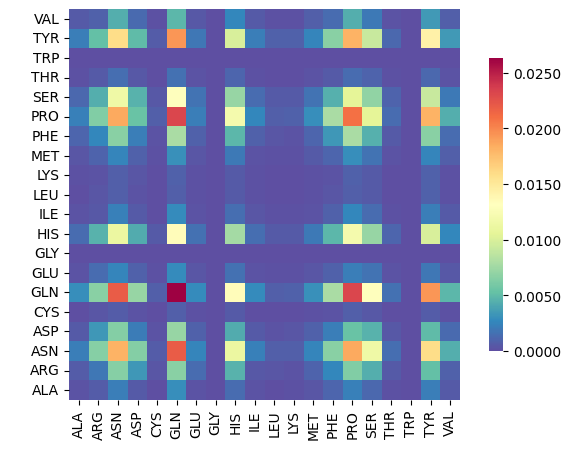

In [22]:
ptools.plot_df(time_contacts_prot_res_type)

### normalized contact frequency by residue abundance

In [23]:
#check abundance of amino acids
res_types_df=ntools.eval_aa_table(contact_meta, name='MUT16_chain')
res_types_df.head()

/home/lucia/cc/cascade_computing/src/compute/utils/toolbox_normalization.py:77: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  res_df.groupby(['struc_id','res_type'])
/home/lucia/cc/cascade_computing/src/compute/utils/toolbox_normalization.py:90: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  res_df.groupby(['prot','res_type'])


prot,MUT16,total,MUT16_chain
res_type,,,
ALA,260.0,260.0,4.0
ARG,390.0,390.0,6.0
ASN,1430.0,1430.0,22.0
ASP,520.0,520.0,8.0
CYS,65.0,65.0,1.0


In [24]:
matrix = np.outer(res_types_df['MUT16_chain'], res_types_df['MUT16_chain'])
MUT16_MUT16_int_res_types = pd.DataFrame(matrix, index=res_types_df.index, columns=res_types_df.index)

In [25]:
#normalize frequency
norm_freq_prot_res_type=ntools.normalize_frequency(time_contacts_prot_res_type,MUT16_MUT16_int_res_types)

./plot


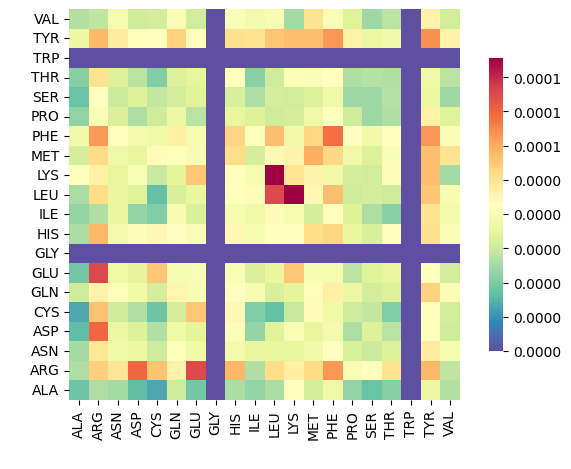

In [26]:
ptools.plot_df(norm_freq_prot_res_type)

#### contact lifetime distribution

In [27]:
job.document['res_type_perc']

'./data_MUT16_FRR/54544235add59ef9295f39739c202cb5/results_files/MUT16_FFR_atm_analysis_MUT16_65_54544235add59ef9295f39739c202cb5_res_type_list_percistance_distribution_pivot.parquet'

In [28]:
res_type_perc = pd.read_parquet(job.document['res_type_perc'])
res_type_perc

res_type_b,ALA,ARG,ASN,ASP,CYS,GLN,GLU,GLY,HIS,ILE,LEU,LYS,MET,PHE,PRO,SER,THR,TRP,TYR,VAL
res_type_a,,,,,,,,,,,,,,,,,,,,
ALA,"[2, 1, 1, 1, 1, 1, 1, 1, 1, 4, 1, 14, 1, 2, 1,...","[2, 1, 1, 1, 1, 1, 1, 5, 2, 1, 2, 1, 178, 1, 2...","[26, 43, 87, 5, 157, 32, 2, 8, 22, 67, 118, 15...","[1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, ...","[1, 1, 1, 2, 1, 1, 1, 1, 1, 1, 1, 1, 1, 2, 3, ...","[1, 1, 1, 1, 2, 1, 2, 1, 1, 7, 2, 7, 6, 1, 1, ...","[10, 8, 4, 2, 7, 1, 25, 4, 2, 2, 5, 2, 1, 1, 8...",[],"[1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 3, 32, 13, 1...","[79, 1, 2, 1, 1, 1, 4, 2, 1, 1, 1, 1, 1, 1, 1,...","[1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 3, 1, 1, 2, ...","[1, 1, 1, 2, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, ...","[158, 3, 1, 1, 1, 1, 2, 6, 1, 2, 4, 2, 1, 2, 2...","[3, 1, 5, 1, 7, 2, 2, 2, 2, 1, 1, 2, 2, 1, 2, ...","[158, 1, 1, 1, 1, 2, 1, 1, 2, 1, 473, 1273, 29...","[1, 8, 10, 3, 1, 11, 1, 3, 3, 1, 6, 3, 2, 1, 1...","[1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, ...",[],"[3, 18, 5, 4, 2, 1, 6, 5, 103, 47, 176, 272, 1...","[1, 1, 2, 1, 1, 2, 2, 2, 2, 1, 1, 1, 1, 1, 1, ..."
ARG,"[1, 1, 3, 3, 9, 4, 1, 1, 2, 6, 1, 1, 1, 1, 1, ...","[1, 1, 140, 30, 5, 1, 2, 2, 1, 1, 1, 1, 1, 7, ...","[158, 1, 3, 1, 1, 1, 1, 1, 8, 1, 2, 6, 1, 3, 1...","[1, 4, 1, 1, 3, 2, 1, 1, 1, 2, 1, 1, 1, 1, 1, ...","[1, 9, 4, 3, 7, 2, 2, 3, 1, 8, 1, 7, 1, 1, 1, ...","[1, 1, 1, 1, 1, 1, 1, 1, 4, 1, 3, 1, 1, 1, 1, ...","[1, 1, 2, 1, 1, 2, 1, 2, 2, 1, 1, 1, 1, 1, 2, ...",[],"[6, 1, 3, 2, 3, 2, 4, 1, 12, 2, 4, 4, 1, 4, 30...","[1, 2, 6, 1, 1, 2, 47, 14, 18, 9, 22, 8, 1, 6,...","[1, 1, 1, 1, 1, 1, 2, 1, 1, 2, 2, 2, 2, 2, 1, ...","[1, 1, 16, 4, 19, 2, 4, 1, 5, 1, 1, 1, 1, 3, 1...","[1, 1, 1, 1, 1, 3, 1, 3, 1, 1, 5, 1, 1, 2, 3, ...","[2, 1, 1, 3, 7, 5, 1, 1, 7, 2, 1, 3, 2, 1, 2, ...","[2, 1, 6, 1, 1, 2, 1, 2, 1, 1, 1, 2, 3, 1, 4, ...","[1, 1, 2, 1, 1, 2, 3, 1, 1, 1, 1, 1, 1, 1, 1, ...","[1, 6, 10, 18, 1, 1, 1, 3, 12, 6, 28, 8, 2, 1,...",[],"[7900, 1, 1, 1, 1, 1, 1, 2, 1, 1, 1, 2, 2, 1, ...","[1, 2, 1, 3, 1, 1, 2, 1, 1, 1, 2, 1, 7, 1, 1, ..."
ASN,"[4, 1, 1, 5, 6, 3, 1, 2, 2, 1, 1, 1, 1, 3, 3, ...","[6, 2, 4, 8, 20, 2, 1, 1, 1, 1, 4, 5, 2, 1, 1,...","[1, 1, 1, 1, 1, 1, 1, 2, 1, 2, 1, 1, 1, 1, 2, ...","[158, 1, 3, 1, 1, 2, 1, 133, 15, 2, 1, 1, 4, 1...","[2, 1, 1, 1, 12, 5, 1, 3, 2, 8, 2, 3, 2, 9, 1,...","[1, 1, 1, 1, 1, 2, 3, 3, 1, 1, 1, 2, 1, 1, 1, ...","[5, 3, 1, 1, 1, 1, 2, 1, 3, 1, 2, 1, 1, 5, 2, ...",[],"[1, 178, 18, 1, 1, 1, 1, 2, 16, 1, 1, 6, 6, 1,...","[1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 11, 6, 1, 2,...","[2, 1, 1, 1, 1, 1, 1, 1, 2, 1, 1, 1, 38, 4, 1,...","[1, 1, 1, 1, 1, 1, 1, 1, 2, 1, 1, 1, 1, 1, 1, ...","[1, 11, 2, 6, 2, 1, 8, 1, 5, 1, 1, 2, 1, 1, 1,...","[1, 1, 1, 1, 1, 2, 1, 2, 1, 1, 6, 3, 1, 1, 1, ...","[2, 3, 1, 3, 15, 1, 1, 1, 7, 1, 10, 2, 2, 24, ...","[1, 1, 158, 113, 5, 18, 9, 1, 79, 1, 1, 1, 49,...","[1, 1, 1, 1, 1, 1, 1, 2, 1, 2, 1, 2, 1, 1, 1, ...",[],"[1, 1, 5, 7, 1, 1, 1, 1, 1, 1, 1, 13, 2, 1, 4,...","[1, 1, 1, 1, 1, 1, 1, 1, 1, 2, 1, 1, 2, 1, 1, ..."
ASP,"[1, 1, 2, 1, 1, 1, 1, 1, 1, 1, 1, 3, 1, 3, 2, ...","[1, 1, 1, 1, 158, 1, 2, 10, 10, 10, 18, 4, 378...","[1, 2, 1, 3, 9, 5, 3, 2, 1, 1, 1, 1, 4, 3, 3, ...","[6, 2, 5, 2, 1, 2, 2, 1, 1, 1, 4, 1, 1, 4, 1, ...","[2, 1, 1, 1, 1, 1, 2, 3, 1, 1, 1, 2, 1, 1, 1, ...","[158, 1, 1, 2, 2, 1, 1, 1, 1, 53, 150, 1, 3, 1...","[5, 1, 1, 21, 18, 55, 7, 4, 67, 1, 1, 1, 1, 2,...",[],"[1, 1, 2, 1, 1, 1, 1, 1, 2, 1, 3, 1, 1, 1, 11,...","[3, 1, 1, 1, 3, 3, 1, 1, 3, 1, 1, 1, 9, 2, 1, ...","[158, 1, 607, 1, 1, 5, 55, 1, 1, 1, 79, 3, 1, ...","[1, 1, 2, 1, 4, 1, 5, 7, 3, 1, 2, 3, 6, 4, 1, ...","[1, 1, 1, 1, 1, 1, 1, 2, 2, 2, 1, 3, 2, 1, 1, ...","[4, 1, 2, 2, 4, 2, 1, 1, 5, 1, 2, 2, 1, 1, 1, ...","[9, 1, 45, 104, 3, 14, 13, 1, 1, 1, 3, 1, 1, 1...","[1, 1, 1, 1, 2, 1, 1, 1, 1, 1, 1, 1, 1, 1, 2, ...","[1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 2, 1, ...",[],"[1, 2, 1, 2, 1, 2, 1, 1, 1, 1, 1, 1, 2, 2, 1, ...","[1, 1, 1, 1, 1, 1, 2, 1, 4, 2, 1, 2, 1, 1, 1, ..."
CYS,"[1, 1, 1, 1, 1, 1, 1, 3, 1, 1, 1, 1, 1, 1, 1, ...","[1, 1, 4, 5, 3, 1, 1, 2, 2, 1, 1, 1, 

/tmp/ipykernel_179517/3398952919.py:11: FutureWarning: DataFrame.applymap has been deprecated. Use DataFrame.map instead.
  mat_filtered = mat.applymap(
/tmp/ipykernel_179517/3398952919.py:21: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.
  cmap = cm.get_cmap("tab20", len(unique_pairs))


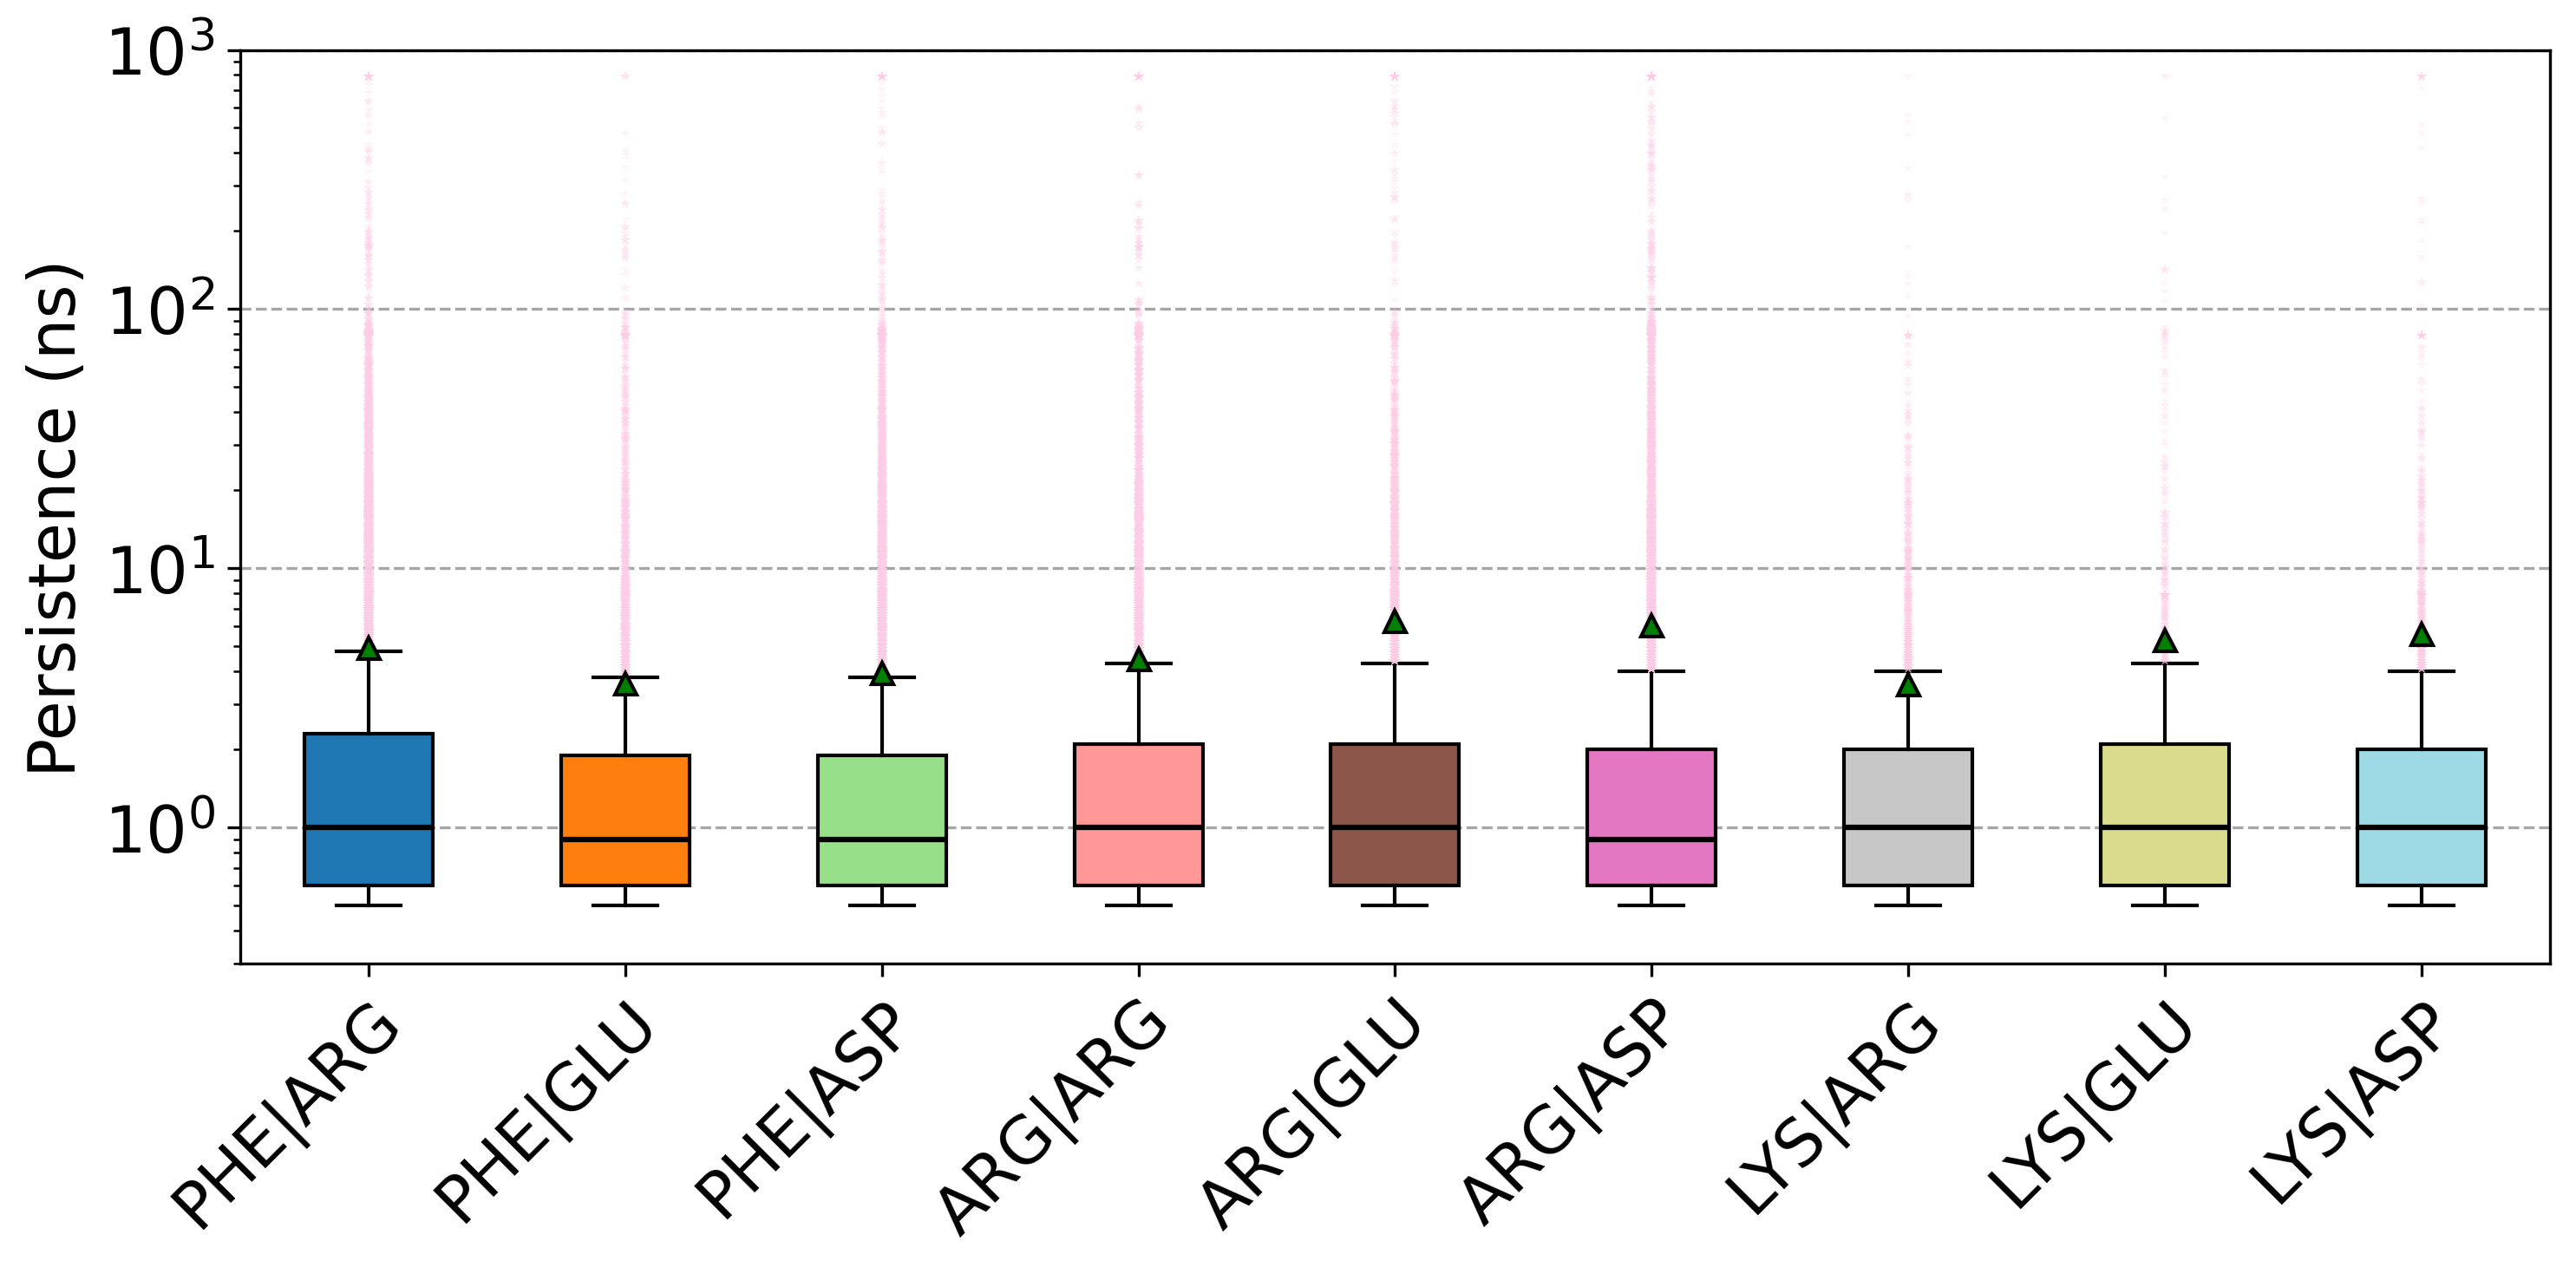

In [29]:
#what do plot
output_filename = '' 
val_title=''
query=["MUT16","MUT16"]
subquery=np.array([["PHE","ARG"],["ARG","GLU"],["LYS","ASP"]])


mat=ntools.query_slice(query, subquery,res_type_perc )
#mat=res_type_perc
#filter
mat_filtered = mat.applymap(
lambda lst: [x for x in lst if x >= 5] if isinstance(list(lst), list) else []
)
#data pairs for labeling with color map
all_pairs = list(itertools.product(mat_filtered.index, mat_filtered.columns))
joined_all_pairs = ["_".join(map(str, l)) for l in all_pairs]

unique_pairs = list(dict.fromkeys(joined_all_pairs))

import matplotlib.cm as cm
cmap = cm.get_cmap("tab20", len(unique_pairs))
pair_to_color = {p: cmap(i) for i, p in enumerate(unique_pairs)}

# pass the DICT (not the list)
color_map = pair_to_color

ptools.plot_boxplots_whisker_scaled(mat_filtered, output_filename, color_map,val_title, scale=0.1)

/tmp/ipykernel_179517/153195334.py:1: FutureWarning: DataFrame.applymap has been deprecated. Use DataFrame.map instead.
  mat_filtered = res_type_perc.applymap(
/tmp/ipykernel_179517/153195334.py:11: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.
  cmap = cm.get_cmap("tab20", len(unique_pairs))


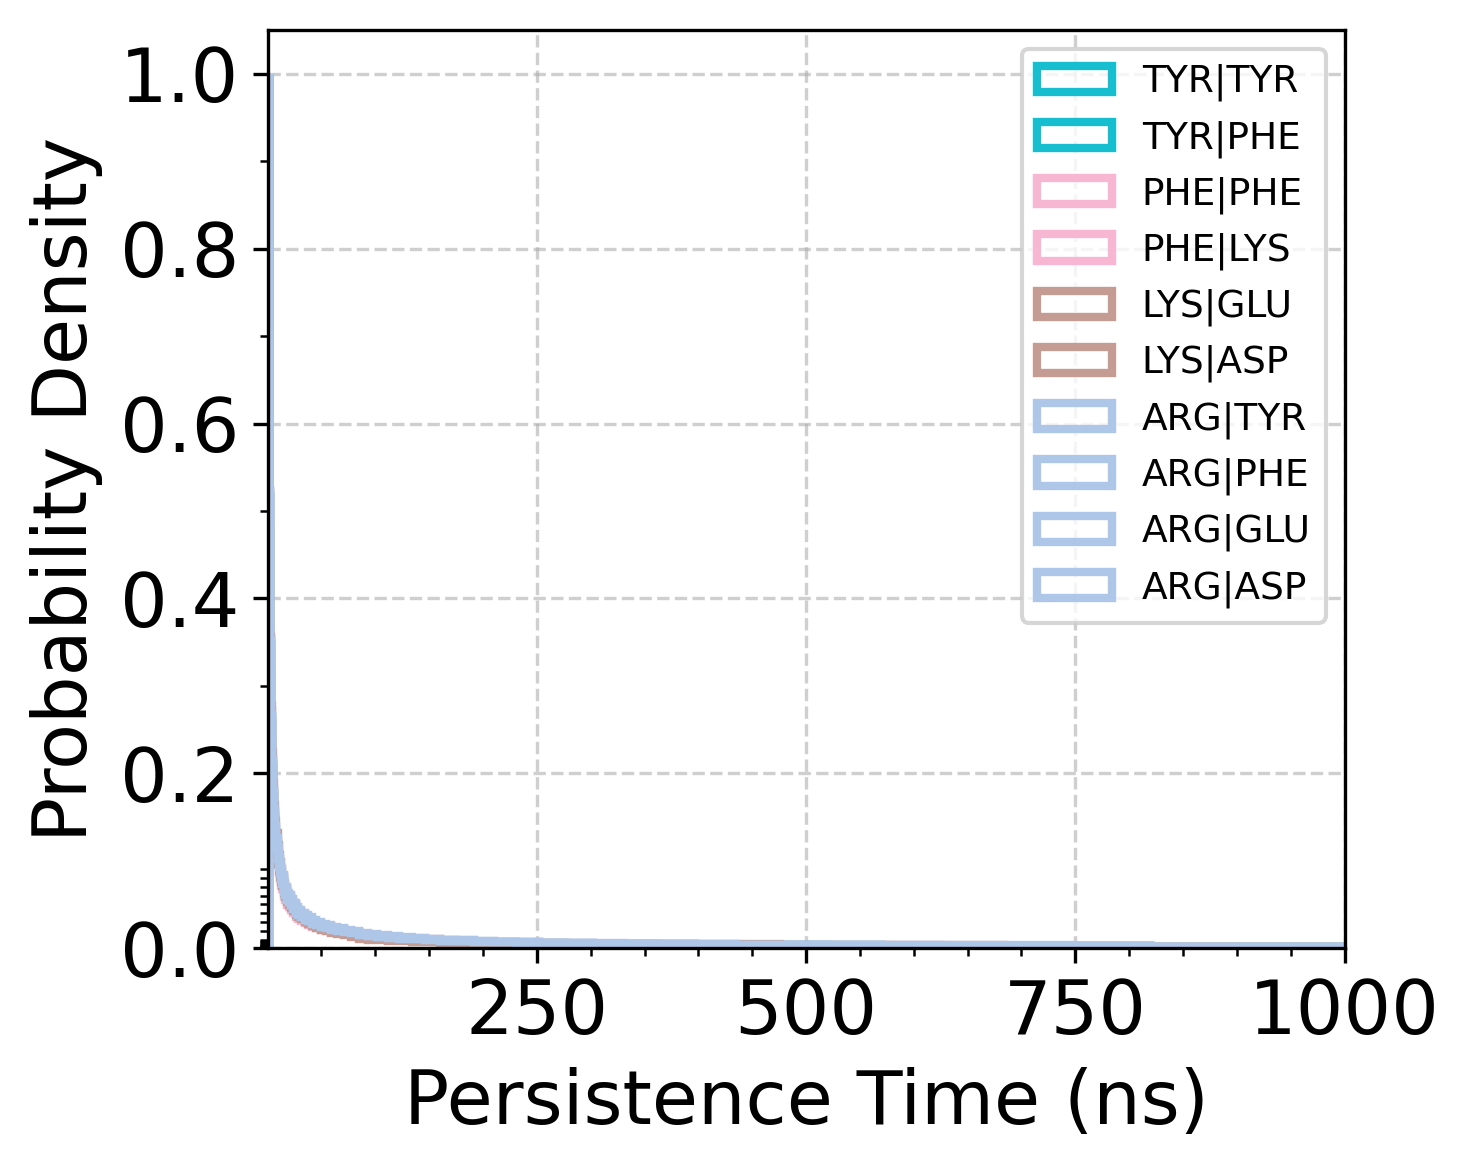

In [30]:
mat_filtered = res_type_perc.applymap(
lambda lst: [x for x in lst if x >= 0] if isinstance(list(lst), list) else []
)
#data pairs for labeling with color map
all_pairs = list(itertools.product(mat_filtered.index, mat_filtered.columns))
joined_all_pairs = ["_".join(map(str, l)) for l in all_pairs]

unique_pairs = list(dict.fromkeys(joined_all_pairs))

import matplotlib.cm as cm
cmap = cm.get_cmap("tab20", len(unique_pairs))
pair_to_color = {p: cmap(i) for i, p in enumerate(unique_pairs)}

# pass the DICT (not the list)
color_map = pair_to_color

ptools.plot_hist(mat_filtered, output_filename, color_map,val_title)

In [ ]:
ptools.plot_hist(mat_filtered, output_filename, color_map,val_title)

In [31]:
#derive pivot